In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [4]:
class chatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    


In [5]:
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [6]:
def chat_node(state:chatState):
    messages = state["messages"]

    response = llm.invoke(messages)

    return {'messages': [response]}


In [9]:
checkpointer = MemorySaver()
graph = StateGraph(chatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')

chatbot = graph.compile(checkpointer = checkpointer)

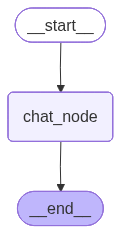

In [10]:
chatbot

In [12]:

thread_id = '1'

while True:

    user_input = input()

    print(f"user : {user_input}")
    initial_state = {
        'messages': [HumanMessage(content = user_input)]
    }

    config = {'configurable': {'thread_id': thread_id}}


    response = chatbot.invoke(initial_state, config=config)['messages'][-1].content
    print(f"AI: {response}")

    if user_input in ["bye","exit", "stop"]:
        break 


user : hi
AI: Hi! How are you today? Is there something I can help you with, or would you like to chat?
user : how are you
AI: I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have!

How about you? How's your day going so far?
user : my name is shakeb
AI: Nice to meet you, Shakeb! That's a unique name. What's your favorite thing to do or a hobby that you're passionate about? I'm here to chat and learn more about you!
user : do you remember my name
AI: I do remember your name, Shakeb! You told me earlier, and I'm designed to recall information within our conversation. So, it's nice to catch up with you again, Shakeb! How's life treating you?
user : bye
AI: It was nice chatting with you, Shakeb! Have a great day and feel free to come back and chat with me anytime. Bye!


In [30]:
chatbot.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='3ad2c2ef-74c5-4cee-8c64-f58100bd41eb'), AIMessage(content='Hi! How are you today? Is there something I can help you with, or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 11, 'total_tokens': 35, 'completion_time': 0.054447371, 'completion_tokens_details': None, 'prompt_time': 9.9748e-05, 'prompt_tokens_details': None, 'queue_time': 0.065681302, 'total_time': 0.054547119}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6114-6ec9-7171-a853-4af476d133ca-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 24, 'total_tokens': 35}), HumanMessage(content='how are you', additional_kwargs={}, response_me